In [1]:
import pystac_client
import planetary_computer
import odc.stac

In [2]:
import matplotlib.pyplot as plt

from pystac.extensions.eo import EOExtension as eo

### Data Access

In [4]:
catalog = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

### AOI & TIME

In [7]:

bbox = [81.5781, 25.7294, 81.7775, 25.9090]

time = "2025-11-05/2025-11-20"

In [ ]:
search = catalog.search(
    collections=['landsat-c2-l2'],
    bbox=bbox,
    datetime=time,
    query={'eo:cloud_cover': {'lt': 10}},
)

items = search.get_all_items()
print(f'returned {len(items)} items')

returned 1 items


In [10]:
type(items)

pystac.item_collection.ItemCollection

In [21]:
items[0].assets.title

AttributeError: 'dict' object has no attribute 'title'

In [9]:
selected_item = min(items, key=lambda item: eo.ext(item).cloud_cover)

print(
    f"Choosing {selected_item.id} from {selected_item.datetime.date()}"
    + f" with {selected_item.properties['eo:cloud_cover']}% cloud cover"
)

Choosing LC09_L2SP_143042_20251109_02_T1 from 2025-11-09 with 3.3% cloud cover


In [23]:
max_key_length = len(max(selected_item.assets, key=len))
for key, asset in selected_item.assets.items():
    print(f"{key.rjust(max_key_length)}: {asset.title}")

              qa: Surface Temperature Quality Assessment Band
             ang: Angle Coefficients File
             red: Red Band
            blue: Blue Band
            drad: Downwelled Radiance Band
            emis: Emissivity Band
            emsd: Emissivity Standard Deviation Band
            lwir: Surface Temperature Band
            trad: Thermal Radiance Band
            urad: Upwelled Radiance Band
           atran: Atmospheric Transmittance Band
           cdist: Cloud Distance Band
           green: Green Band
           nir08: Near Infrared Band 0.8
          swir16: Short-wave Infrared Band 1.6
          swir22: Short-wave Infrared Band 2.2
         mtl.txt: Product Metadata File (txt)
         mtl.xml: Product Metadata File (xml)
        cloud_qa: Cloud Quality Assessment Band
        mtl.json: Product Metadata File (json)
        qa_pixel: Pixel Quality Assessment Band
       qa_radsat: Radiometric Saturation and Dropped Pixel Quality Assessment Band
   atmos_opacity: 

### Rendering naturla color image of AOI

In [10]:
bands_of_interest = ['nir08' , 'red','green','blue']
data = odc.stac.load(
    [selected_item],
    bands=bands_of_interest,
    bbox=bbox,
).isel(time=0)
data

<xarray.Dataset> Size: 4MB
Dimensions:      (y: 668, x: 670)
Coordinates:
  * y            (y) float64 5kB 2.866e+06 2.866e+06 ... 2.846e+06 2.846e+06
  * x            (x) float64 5kB 5.579e+05 5.579e+05 ... 5.78e+05 5.78e+05
    spatial_ref  int32 4B 32644
    time         datetime64[ns] 8B 2025-11-09T05:01:29.332687
Data variables:
    nir08        (y, x) uint16 895kB 16714 16618 16207 ... 15949 16484 16233
    red          (y, x) uint16 895kB 10381 10868 11495 ... 12852 13109 13012
    green        (y, x) uint16 895kB 10910 11195 11592 ... 12433 12551 12502
    blue         (y, x) uint16 895kB 9355 9658 10101 10629 ... 10988 11110 11141

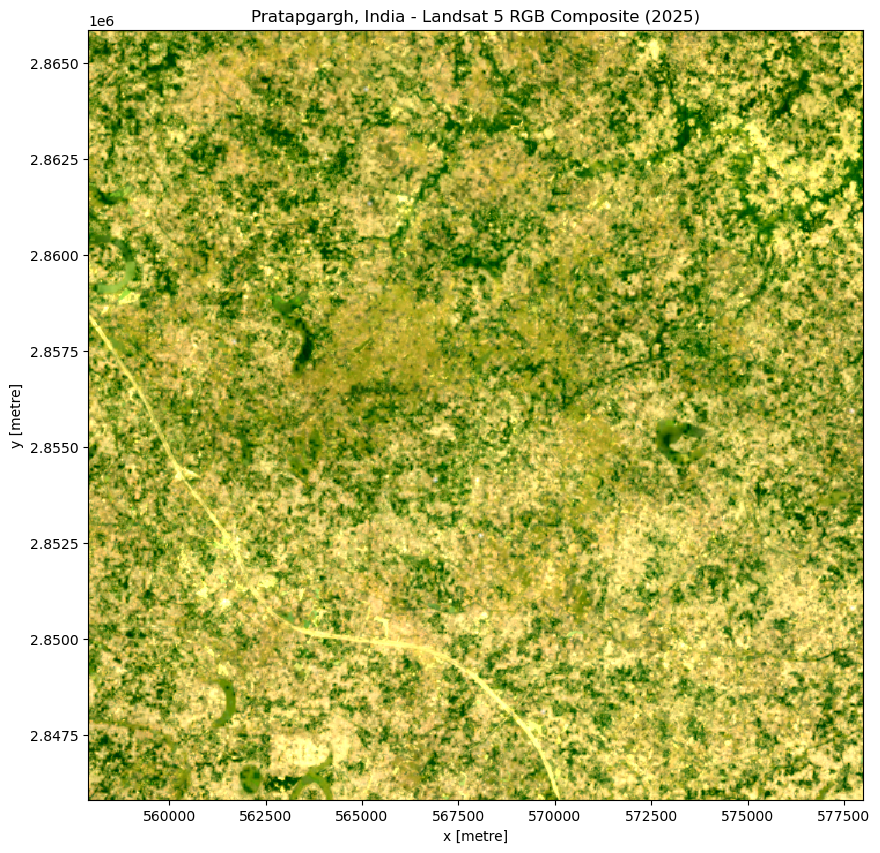

In [11]:
fig, ax = plt.subplots(figsize=(10, 10))

data[["red", "green", "blue"]].to_array().plot.imshow(robust=True, ax=ax)
ax.set_title("Pratapgargh, India - Landsat 5 RGB Composite (2025)");

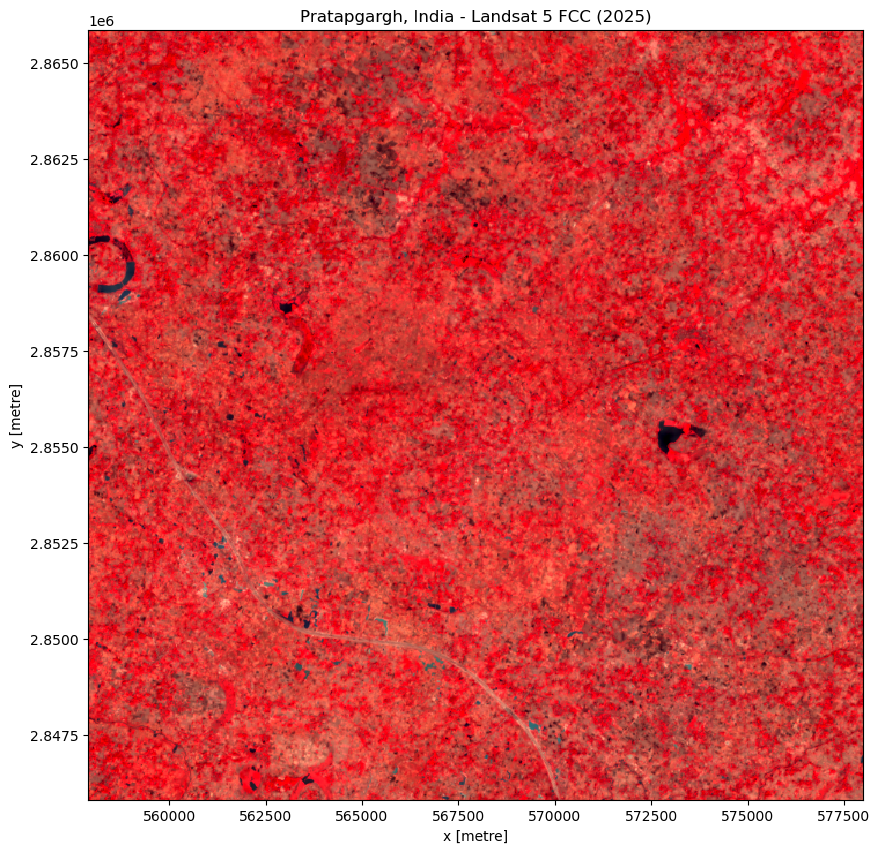

In [12]:
fig, ax = plt.subplots(figsize=(10, 10))

data[["nir08", "red", "green"]].to_array().plot.imshow(robust=True, ax=ax)
ax.set_title("Pratapgargh, India - Landsat 5 FCC (2025)");

In [13]:
from pathlib import Path
out_path = Path("landsat5_pratapgarh_2025_2.txt")
count=0
with out_path.open('w', encoding='utf-8') as f:
    for it in items:
        for key, asset in it.assets.items():
            f.write(asset.title + ': ')
            f.write(asset.href + '\n')
            count+=1
print(f'Download links for {count} items written to {out_path}')

Download links for 25 items written to landsat5_pratapgarh_2025_2.txt


In [24]:
data.sizes

Frozen({'y': 668, 'x': 670})